# Chapter 10 (extra) — The analytical thin-layer / thin-film response

The main chapter notebook builds the *fully implicit finite-difference* solvers
for thin-layer and thin-film cyclic voltammetry. This companion notebook covers
the **analytical half** of Honeychurch's Chapter 10 and an independent numerical
cross-check:

1. **Laplace-transform derivation** of the thin-film current, done symbolically
   with `sympy`, ending in the closed-form transfer function
   $i(s) = -\dfrac{\xi}{1+\xi}\,\dfrac{\tanh\sqrt s}{\sqrt s}$.
2. The **theta-function inverse transform** of the kernel
   $\tanh\sqrt s/\sqrt s$, with its two physically meaningful limits
   (fast sweep $\to$ Cottrell; slow sweep $\to$ a single exponential).
3. A **theta-convolution worked example** that produces the thin-film
   voltammogram directly from the Laplace solution, *without a spatial grid*.
4. A **method-of-lines solver** (the `NDSolve` analogue): discretise space,
   integrate the stiff ODE system in time. This is an *independent*
   discretisation from the implicit tridiagonal scheme, so agreement is a
   genuine cross-check.

All reusable pieces live in `serm.ch10_analytical`; the finite-difference
reference is `serm.ch10_thin_layers_and_films`.

Dimensionless conventions match the main chapter: $\theta = nF(E-E^{0\prime})/RT$,
$\xi = e^{\theta}$, the single controlling group $\mathbb{L} = L^2\sigma/D$, and
the dimensionless current $\chi = i/(nFAc^* L\sigma)$.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
%matplotlib inline

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from serm.ch10_analytical import (
    theta2_kernel,
    cottrell_kernel,
    thin_film_convolution,
    method_of_lines_cv,
)
from serm.ch10_thin_layers_and_films import simulate_thin_layer, simulate_thin_film
print("imports OK")

imports OK


## 1. Laplace-transform derivation of the thin-film current

Fick's second law in dimensionless form on the confined domain $x\in[0,1]$ with
the uniform initial condition $c(x,0)=1$ is

$$\frac{\partial c}{\partial t} = \frac{\partial^2 c}{\partial x^2}.$$

Taking the Laplace transform in time ($c\to\bar C(x,s)$) and using
$c(x,0)=1$ turns the PDE into the ODE

$$\bar C'' - s\,\bar C + 1 = 0,
\qquad
\bar C(x,s) = \frac1s + C_1\cosh(\sqrt s\,x) + C_2\sinh(\sqrt s\,x).$$

We verify the general solution and impose the boundary conditions symbolically.

In [2]:
x, s = sp.symbols("x s", positive=True)
C1, C2, xi = sp.symbols("C1 C2 xi")   # constants may be negative; do not assume positive
sq = sp.sqrt(s)
Cbar = 1/s + C1*sp.cosh(sq*x) + C2*sp.sinh(sq*x)

# (a) it satisfies the transformed PDE  Cbar'' - s Cbar + 1 = 0
residual = sp.simplify(sp.diff(Cbar, x, 2) - s*Cbar + 1)
print("PDE residual (must be 0):", residual)

# (b) thin-film wall: zero flux at x = 1  ->  Cbar'(1) = 0  fixes C2
C2_sol = sp.solve(sp.Eq(sp.diff(Cbar, x).subs(x, 1), 0), C2)[0]
print("C2 =", sp.simplify(C2_sol))
Cbar_film = Cbar.subs(C2, C2_sol)

PDE residual (must be 0): 0
C2 = -C1*tanh(sqrt(s))


The wall condition forces $C_2 = -C_1\tanh\sqrt s$. The surface flux (the
quantity proportional to the current) and the surface concentration are then
both linear in $C_1$:

$$-\bar C'(0) = C_1\sqrt s\,\tanh\sqrt s,
\qquad
\bar C(0) = \frac1s + C_1.$$

For a **reversible** electrode the surface concentration is set by Nernst,
$c(0,t) = 1/(1+\xi)$, i.e. $\bar C(0)=\dfrac{1}{s}\dfrac{1}{1+\xi}$. Eliminating
$C_1$ gives the current transfer function.

In [3]:
flux0 = sp.simplify(-sp.diff(Cbar_film, x).subs(x, 0))   # = C1 sqrt(s) tanh(sqrt s)
Csurf = sp.simplify(Cbar_film.subs(x, 0))                  # = 1/s + C1
print("surface flux  -Cbar'(0) =", flux0)
print("surface conc   Cbar(0)  =", Csurf)

# Reversible surface value Cbar(0) = (1/(1+xi))/s  -> solve for C1, substitute into flux
C1_rev = sp.solve(sp.Eq(Csurf, sp.Rational(1)/(s*(1+xi))), C1)[0]
i_s = sp.simplify(flux0.subs(C1, C1_rev))
print("\ncurrent transfer function  i(s) =", i_s)
print("                                 = -[xi/(1+xi)] * tanh(sqrt s)/sqrt(s)")

surface flux  -Cbar'(0) = C1*sqrt(s)*tanh(sqrt(s))
surface conc   Cbar(0)  = C1 + 1/s

current transfer function  i(s) = -xi*tanh(sqrt(s))/(sqrt(s)*(xi + 1))
                                 = -[xi/(1+xi)] * tanh(sqrt s)/sqrt(s)


So, in Laplace space,

$$\boxed{\,i(s) = -\frac{\xi}{1+\xi}\,\frac{\tanh\sqrt s}{\sqrt s}\,.}$$

Inverting requires the inverse transform of the kernel $\tanh\sqrt s/\sqrt s$.

## 2. The theta-function kernel and its limits

Mathematica (and `sympy`) cannot invert $\tanh\sqrt s/\sqrt s$ in closed form,
but tables of Laplace transforms give

$$\mathcal{L}^{-1}\!\left\{\frac{\tanh\sqrt s}{\sqrt s}\right\}(t)
  = 2\sum_{n=0}^{\infty}\exp\!\Big[-\pi^2 t\,(n+\tfrac12)^2\Big]
  \;=\; \vartheta_2\!\big(0\,\big|\,e^{-\pi^2 t}\big),$$

an EllipticTheta-$\vartheta_2$ series. `serm.ch10_analytical.theta2_kernel`
evaluates it. We confirm it really is the inverse transform by transforming it
back numerically, and we check the two limits that carry the physics:

* **fast sweep** (small $t$): $k(t)\to 1/\sqrt{\pi t}$ — the Cottrell kernel of
  *semi-infinite* diffusion;
* **slow sweep** (large $t$): $k(t)\to 2e^{-\pi^2 t/4}$ — the leading term.

In [4]:
from scipy.integrate import quad

# (a) round-trip: numerically Laplace-transform k(t) and compare to tanh(sqrt s)/sqrt s
def k_scalar(t, N=200):
    n = np.arange(N)
    return 2.0*np.sum(np.exp(-np.pi**2*t*(n+0.5)**2)) if t > 0 else 0.0

print("round-trip check  int_0^inf k(t) e^{-st} dt   vs   tanh(sqrt s)/sqrt s")
for sv in (0.5, 1.0, 4.0):
    val, _ = quad(lambda t: k_scalar(t)*np.exp(-sv*t), 0, 50, limit=400)
    tgt = np.tanh(np.sqrt(sv))/np.sqrt(sv)
    print(f"  s={sv:4.1f}:  numeric={val:.6f}   target={tgt:.6f}   diff={abs(val-tgt):.1e}")

# (b) limits
t_fast = np.array([0.005, 0.01, 0.05])
t_slow = np.array([0.5, 1.0, 2.0])
print("\nfast-sweep limit  k(t) vs 1/sqrt(pi t):")
print("  ", theta2_kernel(t_fast), cottrell_kernel(t_fast))
print("slow-sweep limit  k(t) vs 2 exp(-pi^2 t/4):")
print("  ", theta2_kernel(t_slow), 2*np.exp(-np.pi**2*t_slow/4))

round-trip check  int_0^inf k(t) e^{-st} dt   vs   tanh(sqrt s)/sqrt s
  s= 0.5:  numeric=0.861057   target=0.861057   diff=6.4e-09
  s= 1.0:  numeric=0.761594   target=0.761594   diff=6.4e-09
  s= 4.0:  numeric=0.482014   target=0.482014   diff=5.4e-10

fast-sweep limit  k(t) vs 1/sqrt(pi t):
   [7.97884561 5.64189584 2.52313251] [7.97884561 5.64189584 2.52313252]
slow-sweep limit  k(t) vs 2 exp(-pi^2 t/4):


   [0.58245599 0.16960995 0.01438377] [0.58242587 0.16960994 0.01438377]


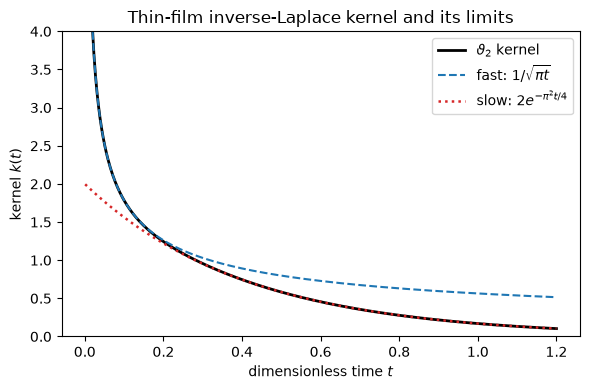

In [5]:
# Visualise the kernel and its two asymptotes.
t = np.linspace(1e-3, 1.2, 600)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, theta2_kernel(t), "k-", lw=2, label=r"$\vartheta_2$ kernel")
ax.plot(t, cottrell_kernel(t), "C0--", lw=1.5, label=r"fast: $1/\sqrt{\pi t}$")
ax.plot(t, 2*np.exp(-np.pi**2*t/4), "C3:", lw=1.8, label=r"slow: $2e^{-\pi^2 t/4}$")
ax.set_xlabel("dimensionless time $t$")
ax.set_ylabel(r"kernel $k(t)$")
ax.set_ylim(0, 4)
ax.legend()
ax.set_title("Thin-film inverse-Laplace kernel and its limits")
fig.tight_layout()
plt.show()

The kernel hugs the Cottrell curve at short times (fast sweep / semi-infinite)
and decays as the single exponential $2e^{-\pi^2 t/4}$ at long times (slow sweep
/ exhausted gap). These are exactly the two regimes Honeychurch identifies.

## 3. Theta-convolution worked example

The time-domain current is the convolution of the kernel with the rate of change
of surface coverage. Writing $\xi(t)=e^{\theta(t)}$ for the triangular sweep
$\theta(t)=\theta_0-\mathbb{L}\,t$ (and back),

$$\chi(t) = -\frac{1}{\mathbb{L}}
  \int_0^t \frac{\mathrm d}{\mathrm d\tau}\!\left[\frac{\xi(\tau)}{1+\xi(\tau)}\right]
  \, k(t-\tau)\,\mathrm d\tau.$$

`thin_film_convolution` evaluates this with an FFT convolution — **no spatial
grid**. We compare it to the finite-difference thin-film solver from the main
chapter, and we check that it *converges* to the FD result as the time grid is
refined (Authoring Spec §5, tier 3).

In [6]:
L_param = 1.0
fd = simulate_thin_film(L_param=L_param, ks_dim=1.0e4)   # reversible FD reference
peak_fd = np.abs(fd.current).max()

peaks = {}
for nh in (3000, 6000, 12000):
    cv = thin_film_convolution(L_param=L_param, n_half=nh)
    peaks[nh] = np.abs(cv.current).max()
    print(f"convolution peak (n_half={nh:5d}) = {peaks[nh]:.4f}")
print(f"finite-difference peak           = {peak_fd:.4f}")

# refinement should be monotone increasing toward the FD peak (singular tau->0 quadrature)
assert peaks[3000] < peaks[6000] < peaks[12000] <= peak_fd + 1e-3, "convolution not converging to FD"
print("PASS: convolution converges toward the FD peak as the grid refines (tier 3).")

convolution peak (n_half= 3000) = 0.2255
convolution peak (n_half= 6000) = 0.2303


convolution peak (n_half=12000) = 0.2337
finite-difference peak           = 0.2413
PASS: convolution converges toward the FD peak as the grid refines (tier 3).


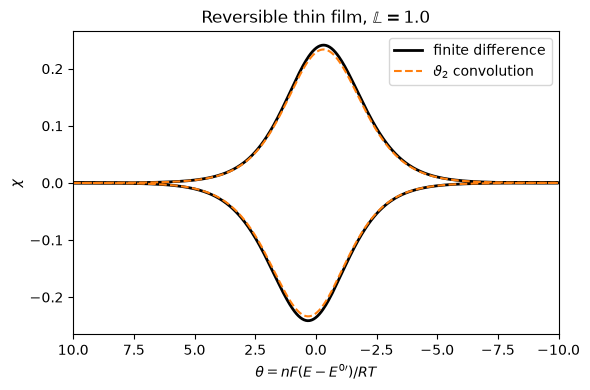

In [7]:
# Overlay the converged convolution curve on the FD voltammogram.
cv = thin_film_convolution(L_param=L_param, n_half=12000)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fd.potential, fd.current, "k-", lw=2, label="finite difference")
ax.plot(cv.theta, cv.current, "C1--", lw=1.5, label=r"$\vartheta_2$ convolution")
ax.set_xlabel(r"$\theta = nF(E-E^{0\prime})/RT$")
ax.set_ylabel(r"$\chi$")
ax.set_xlim(10, -10)
ax.legend()
ax.set_title(rf"Reversible thin film, $\mathbb{{L}}={L_param}$")
fig.tight_layout()
plt.show()

### Fast-sweep limit recovers semi-infinite diffusion

Swapping the full $\vartheta_2$ kernel for its fast-sweep limit
$1/\sqrt{\pi t}$ turns the convolution into the *semi-infinite* linear-sweep
voltammogram. At large $\mathbb{L}$ (fast sweep) the two kernels must give the
same answer — the thin film has not yet "felt" its far wall. This is the
reduction-to-a-validated-limit check (Authoring Spec §5, tier 2).

In [8]:
L_fast = 50.0
cv_full = thin_film_convolution(L_param=L_fast, n_half=12000, kernel="theta")
cv_cott = thin_film_convolution(L_param=L_fast, n_half=12000, kernel="cottrell")
p_full = np.abs(cv_full.current).max()
p_cott = np.abs(cv_cott.current).max()
print(f"full theta kernel peak    = {p_full:.5f}")
print(f"Cottrell (semi-inf) peak  = {p_cott:.5f}")
rel = abs(p_full - p_cott)/p_cott
print(f"relative difference       = {rel:.2e}")
assert rel < 1e-3, "fast-sweep film does not reduce to semi-infinite diffusion"
print("PASS: at large L the thin-film convolution reduces to semi-infinite LSV (tier 2).")

full theta kernel peak    = 0.06223
Cottrell (semi-inf) peak  = 0.06223
relative difference       = 9.61e-06
PASS: at large L the thin-film convolution reduces to semi-infinite LSV (tier 2).


## 4. Method of lines (the `NDSolve` analogue)

Honeychurch's Chapter 10 also solves the problem with `NDSolve`. The numpy
analogue is the **method of lines**: discretise $x\in[0,1]$ on a grid, leaving a
system of ODEs $\dot c_j = (c_{j+1}-2c_j+c_{j-1})/\Delta x^2$, and integrate in
time with a stiff solver (`scipy.integrate.solve_ivp`, `BDF`).
`method_of_lines_cv` does this for both geometries with the **reversible**
Dirichlet electrode boundary $c(0,t)=1/(1+\xi)$.

Because the spatial *and* temporal discretisations differ entirely from the
implicit tridiagonal scheme, agreement between the two is a strong independent
check (and both agree with the analytic peak $\chi_p=0.25$).

In [9]:
rows = []
for geo, sim in (("layer", simulate_thin_layer), ("film", simulate_thin_film)):
    for Lp in (0.3,):
        mol = method_of_lines_cv(L_param=Lp, geometry=geo)
        ref = sim(L_param=Lp, ks_dim=1.0e4)
        pm, pf = np.abs(mol.current).max(), np.abs(ref.current).max()
        rows.append((geo, Lp, pm, pf))
        print(f"{geo:5s}  L={Lp}:  MOL peak={pm:.4f}   FD peak={pf:.4f}   |diff|={abs(pm-pf):.4f}")

# Tier 1 (closed form) + tier 2 (cross-check vs validated FD).
for geo, Lp, pm, pf in rows:
    assert abs(pm - 0.25) < 5e-3, f"{geo}: MOL peak {pm} not at analytic 0.25"
    assert abs(pm - pf) < 5e-3, f"{geo}: MOL disagrees with FD ({pm} vs {pf})"
print("\nPASS: method-of-lines peaks match the analytic 0.25 (tier 1) AND the FD solver (tier 2).")

layer  L=0.3:  MOL peak=0.2499   FD peak=0.2499   |diff|=0.0001


film   L=0.3:  MOL peak=0.2491   FD peak=0.2489   |diff|=0.0003

PASS: method-of-lines peaks match the analytic 0.25 (tier 1) AND the FD solver (tier 2).


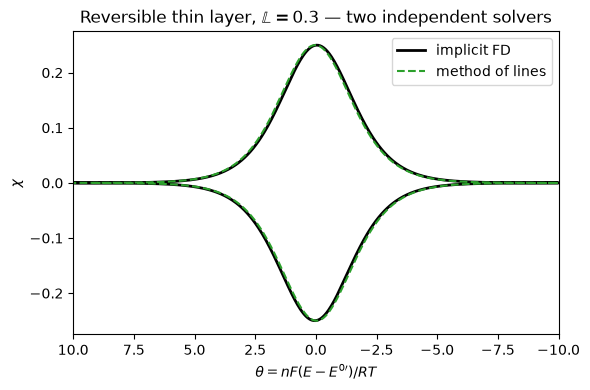

In [10]:
# Overlay MOL and FD voltammograms for the thin-layer cell.
Lp = 0.3
mol = method_of_lines_cv(L_param=Lp, geometry="layer")
ref = simulate_thin_layer(L_param=Lp, ks_dim=1.0e4)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ref.potential, ref.current, "k-", lw=2, label="implicit FD")
ax.plot(mol.theta, mol.current, "C2--", lw=1.5, label="method of lines")
ax.set_xlabel(r"$\theta = nF(E-E^{0\prime})/RT$")
ax.set_ylabel(r"$\chi$")
ax.set_xlim(10, -10)
ax.legend()
ax.set_title(rf"Reversible thin layer, $\mathbb{{L}}={Lp}$ — two independent solvers")
fig.tight_layout()
plt.show()

## Summary

Starting from Fick's second law on a *finite* domain, the Laplace transform
gives a closed-form thin-film current transfer function
$i(s) = -\tfrac{\xi}{1+\xi}\tanh\sqrt s/\sqrt s$, derived here symbolically. Its
inverse is the EllipticTheta-$\vartheta_2$ kernel
$2\sum_n e^{-\pi^2 t(n+1/2)^2}$, whose small-$t$ limit is the Cottrell kernel
(fast sweep $\to$ semi-infinite diffusion) and whose large-$t$ limit is a single
decaying exponential (slow sweep $\to$ exhausted gap).

Three independent routes to the same voltammogram now exist:

* the **implicit finite-difference** solver of the main chapter,
* the grid-free **$\vartheta_2$ convolution** of the Laplace solution, and
* the **method of lines** (`NDSolve` analogue).

They agree with each other and with the analytic thin-layer peak height
$\chi_p = 0.25$, which is the strongest possible (closed-form) validation.

<!-- nav-footer -->

---

[← Chapter 10 — Thin Layers and Thin Films](../10_thin_layers_and_films.ipynb)

[Contents (README)](../../README.md)